## Generacion de visualizaciones: estructura y tipos de graficas en Matplotlib

Este notebook desarrolla la evidencia EV08 con el dataset del proyecto. El flujo incluye preparacion de datos, estructura de grafica, comparacion Pyplot vs OO, graficas univariantes, bivariantes y categoricas, exportacion real con `savefig()` y reflexion final.

In [1]:
%matplotlib inline

from pathlib import Path
from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
ARTIFACTS_DIR = ROOT / "artifacts" / "ev08"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9

df = pd.read_csv(ROOT / "data" / "raw" / "dataset.csv")
df["Database"] = df["Database"].fillna("Sin asignar")
df["Framework"] = df["Framework"].fillna("Sin framework")

level_order = {"Junior": 1, "Semi Senior": 2, "Senior": 3}
df["Level_Score"] = df["Level"].map(level_order).fillna(0).astype(int)
df["Title_Length"] = df["Job_Title"].str.len()
df["Technology_Length"] = df["Technology"].str.len()
df["Framework_Length"] = df["Framework"].str.len()
df["Database_Length"] = df["Database"].str.len()
df["Location_Length"] = df["Location"].str.len()
df["Uses_SQL"] = df["Database"].str.contains("SQL", case=False, na=False).astype(int)
df["Record_Index"] = np.arange(1, len(df) + 1)

numeric_cols = [
    "Experience_Years",
    "Level_Score",
    "Title_Length",
    "Technology_Length",
    "Framework_Length",
    "Database_Length",
    "Location_Length",
    "Uses_SQL",
]

display(Markdown("### Vista previa del dataset consolidado"))
display(df.head())

def save_evidence(fig, name):
    output_path = ARTIFACTS_DIR / f"{name}.png"
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return output_path

### Vista previa del dataset consolidado

,Job_Title,Level,Location,Technology,Framework,Database,Experience_Years,Level_Score,Title_Length,Technology_Length,Framework_Length,Database_Length,Location_Length,Uses_SQL,Record_Index
0,Backend Developer,Junior,Medellín,Python,FastAPI,PostgreSQL,1,1,17,6,7,10,8,1,1
1,Frontend Developer,Junior,Medellín,JavaScript,React,Sin asignar,1,1,18,10,5,11,8,0,2
2,Full Stack Developer,Junior,Medellín,JavaScript,Node.js,MongoDB,1,1,20,10,7,7,8,0,3
3,Backend Developer,Junior,Medellín,Java,Spring Boot,MySQL,1,1,17,4,11,5,8,1,4
4,Data Analyst,Junior,Medellín,Python,Pandas,SQL Server,1,1,12,6,6,10,8,1,5


## A. Estructura de una grafica

La siguiente figura demuestra `figure`, `add_subplot`, titulo, etiquetas, leyenda y anotaciones.

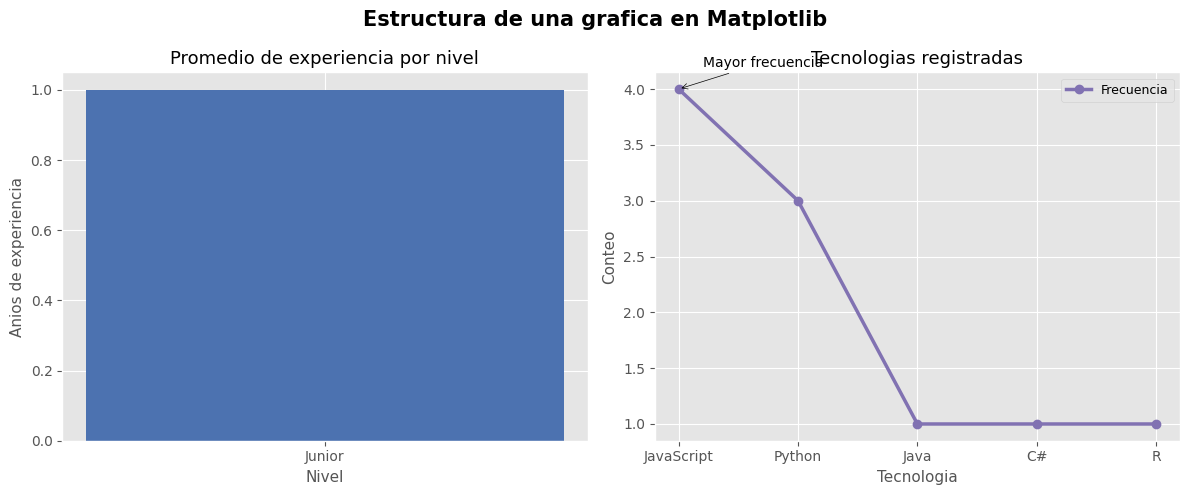

In [2]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

experience_by_level = df.groupby("Level", as_index=False)["Experience_Years"].mean()
ax1.bar(experience_by_level["Level"], experience_by_level["Experience_Years"], color=["#4C72B0", "#55A868", "#C44E52"])
ax1.set_title("Promedio de experiencia por nivel")
ax1.set_xlabel("Nivel")
ax1.set_ylabel("Anios de experiencia")

tech_counts = df["Technology"].value_counts()
ax2.plot(tech_counts.index, tech_counts.values, marker="o", linewidth=2.5, color="#8172B2", label="Frecuencia")
ax2.set_title("Tecnologias registradas")
ax2.set_xlabel("Tecnologia")
ax2.set_ylabel("Conteo")
ax2.legend()
ax2.annotate("Mayor frecuencia", xy=(tech_counts.index[0], tech_counts.iloc[0]), xytext=(0.2, tech_counts.iloc[0] + 0.2), textcoords="data", arrowprops={"arrowstyle": "->", "color": "black"})

fig.suptitle("Estructura de una grafica en Matplotlib", fontsize=15, fontweight="bold")
fig.tight_layout()
save_evidence(fig, "A_estructura_grafica")
plt.show()

## B. Ejemplo Pyplot vs orientacion a objetos

Se comparan dos maneras validas de generar una grafica de barras con Matplotlib.

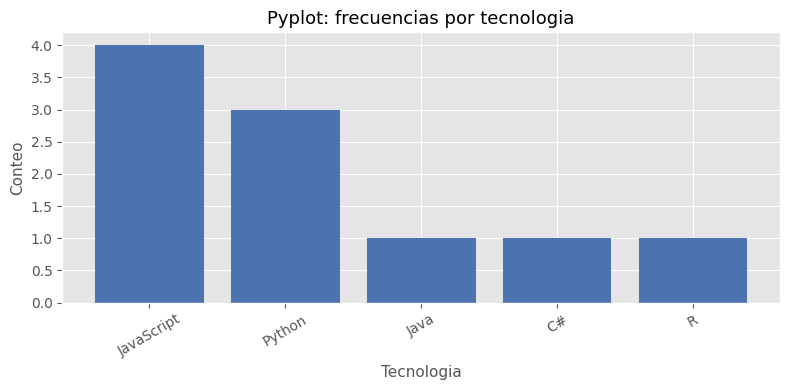

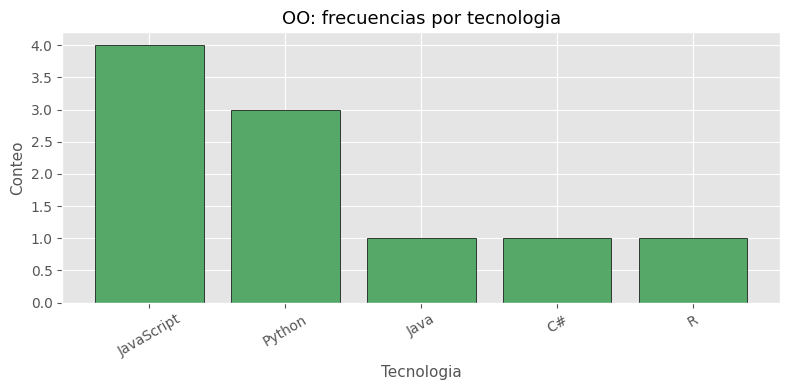

In [3]:
counts = df["Technology"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values, color="#4C72B0")
plt.title("Pyplot: frecuencias por tecnologia")
plt.xlabel("Tecnologia")
plt.ylabel("Conteo")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index, counts.values, color="#55A868", edgecolor="black")
ax.set_title("OO: frecuencias por tecnologia")
ax.set_xlabel("Tecnologia")
ax.set_ylabel("Conteo")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_evidence(fig, "B_pyplot_vs_oo")
plt.show()

## C. Diez graficas univariantes

Las siguientes celdas desarrollan diez visualizaciones univariantes solicitadas para la evidencia.

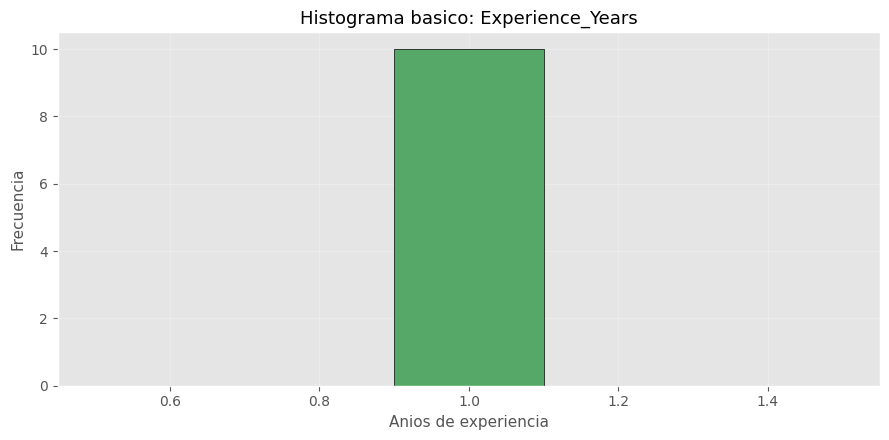

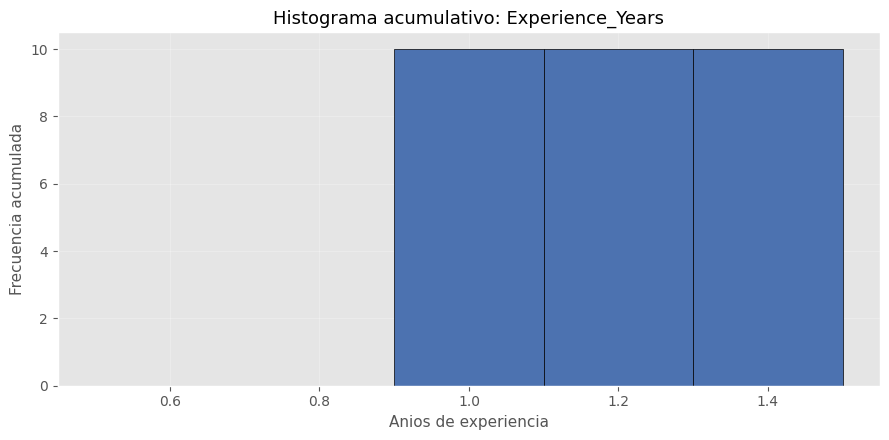

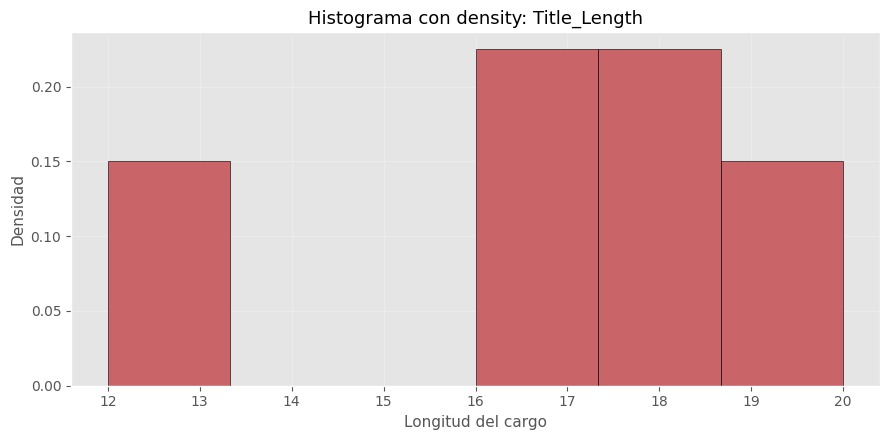

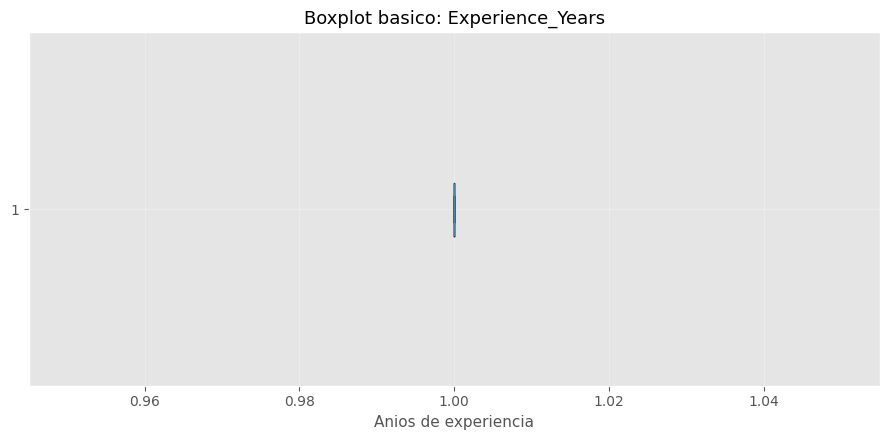

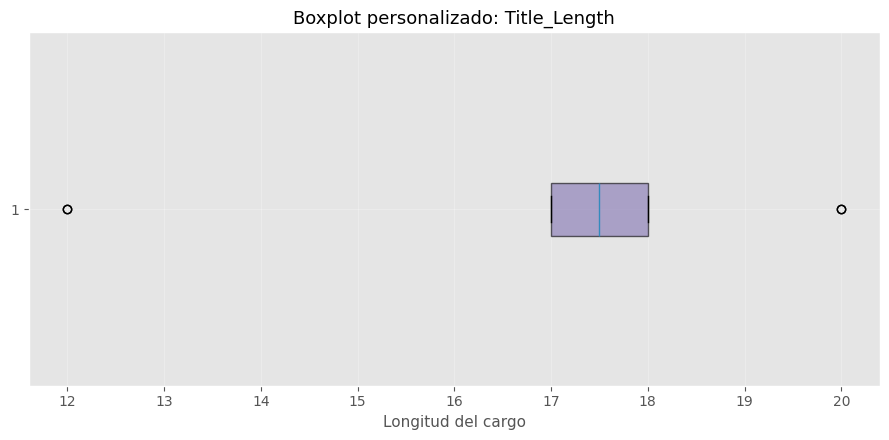

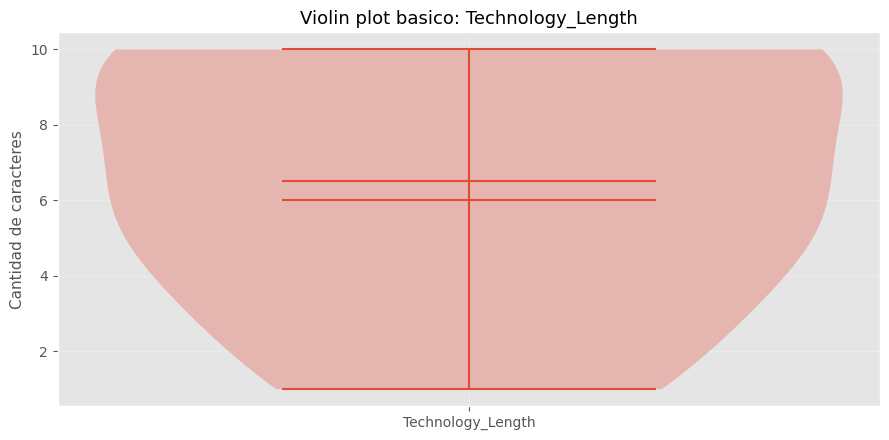

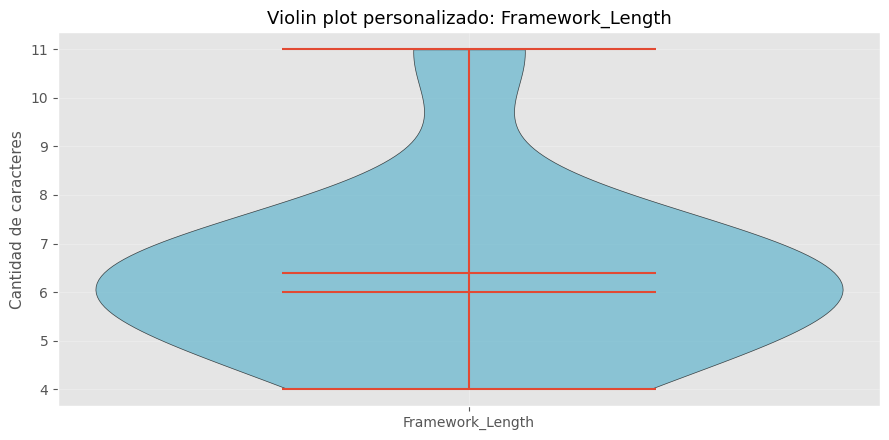

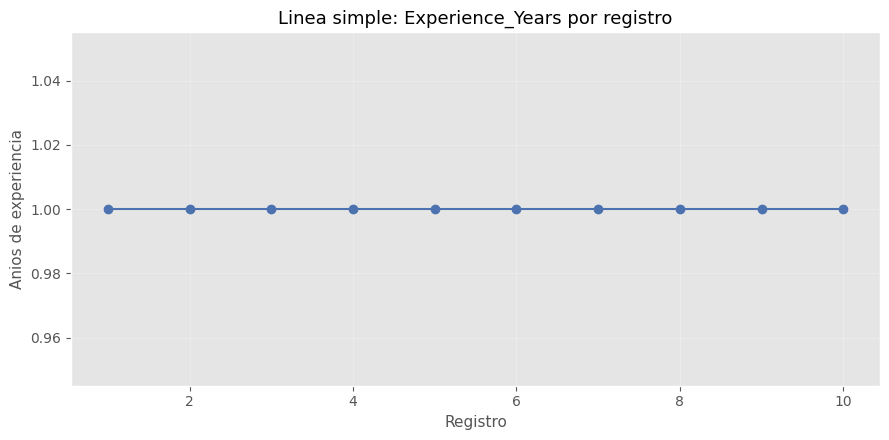

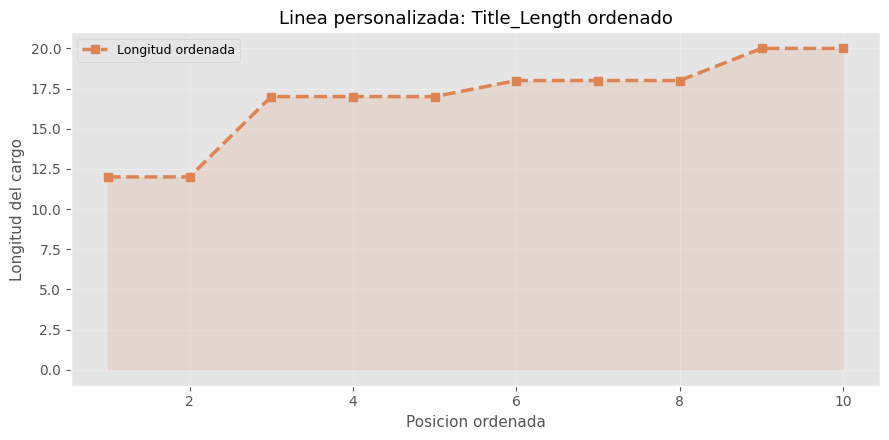

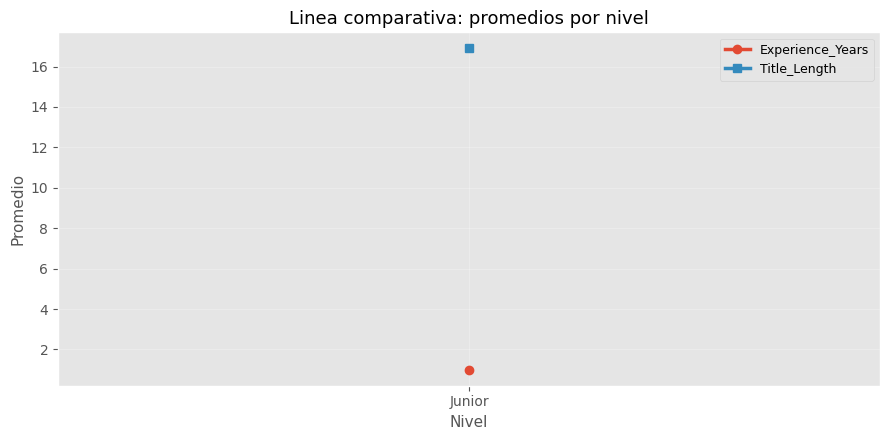

In [4]:
univariate_specs = [
    ("C1_histograma_basico", "Histograma basico: Experience_Years", "experience"),
    ("C2_histograma_acumulativo", "Histograma acumulativo: Experience_Years", "experience"),
    ("C3_histograma_density", "Histograma con density: Title_Length", "title"),
    ("C4_boxplot_basico", "Boxplot basico: Experience_Years", "experience_box"),
    ("C5_boxplot_personalizado", "Boxplot personalizado: Title_Length", "title_box"),
    ("C6_violin_basico", "Violin plot basico: Technology_Length", "tech"),
    ("C7_violin_personalizado", "Violin plot personalizado: Framework_Length", "framework"),
    ("C8_linea_simple", "Linea simple: Experience_Years por registro", "line_simple"),
    ("C9_linea_personalizada", "Linea personalizada: Title_Length ordenado", "line_custom"),
    ("C10_linea_comparativa", "Linea comparativa: promedios por nivel", "line_compare"),
]

for name, title, chart_type in univariate_specs:
    fig, ax = plt.subplots(figsize=(9, 4.5))

    if chart_type == "experience":
        if "acumulativo" in name:
            ax.hist(df["Experience_Years"], bins=5, cumulative=True, color="#4C72B0", edgecolor="black")
            ax.set_ylabel("Frecuencia acumulada")
        else:
            ax.hist(df["Experience_Years"], bins=5, color="#55A868", edgecolor="black")
            ax.set_ylabel("Frecuencia")
        ax.set_xlabel("Anios de experiencia")
    elif chart_type == "experience_box":
        ax.boxplot(df["Experience_Years"], vert=False)
        ax.set_xlabel("Anios de experiencia")
    elif chart_type == "title":
        ax.hist(df["Title_Length"], bins=6, density=True, color="#C44E52", edgecolor="black", alpha=0.85)
        ax.set_xlabel("Longitud del cargo")
        ax.set_ylabel("Densidad")
    elif chart_type == "title_box":
        bp = ax.boxplot(df["Title_Length"], vert=False, patch_artist=True)
        for box in bp["boxes"]:
            box.set(facecolor="#8172B2", alpha=0.6)
        ax.set_xlabel("Longitud del cargo")
    elif chart_type == "tech":
        ax.violinplot(df["Technology_Length"], showmeans=True, showmedians=True)
        ax.set_xticks([1])
        ax.set_xticklabels(["Technology_Length"])
        ax.set_ylabel("Cantidad de caracteres")
    elif chart_type == "framework":
        vp = ax.violinplot(df["Framework_Length"], showmeans=True, showmedians=True, showextrema=True)
        for body in vp["bodies"]:
            body.set_facecolor("#64B5CD")
            body.set_edgecolor("black")
            body.set_alpha(0.7)
        ax.set_xticks([1])
        ax.set_xticklabels(["Framework_Length"])
        ax.set_ylabel("Cantidad de caracteres")
    elif chart_type == "line_simple":
        ax.plot(df["Record_Index"], df["Experience_Years"], marker="o", color="#4C72B0")
        ax.set_xlabel("Registro")
        ax.set_ylabel("Anios de experiencia")
    elif chart_type == "line_custom":
        ordered = df["Title_Length"].sort_values().reset_index(drop=True)
        ax.plot(np.arange(1, len(ordered) + 1), ordered.values, marker="s", linestyle="--", linewidth=2.5, color="#DD8452", label="Longitud ordenada")
        ax.fill_between(np.arange(1, len(ordered) + 1), ordered.values, color="#DD8452", alpha=0.15)
        ax.set_xlabel("Posicion ordenada")
        ax.set_ylabel("Longitud del cargo")
        ax.legend()
    elif chart_type == "line_compare":
        grouped = df.groupby("Level", as_index=False)[["Experience_Years", "Title_Length"]].mean()
        ax.plot(grouped["Level"], grouped["Experience_Years"], marker="o", linewidth=2.5, label="Experience_Years")
        ax.plot(grouped["Level"], grouped["Title_Length"], marker="s", linewidth=2.5, label="Title_Length")
        ax.set_xlabel("Nivel")
        ax.set_ylabel("Promedio")
        ax.legend()

    ax.set_title(title)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_evidence(fig, name)
    plt.show()

## D. Diez graficas bivariantes

Se emplean variables numericas originales y derivadas para analizar relaciones entre pares de variables.

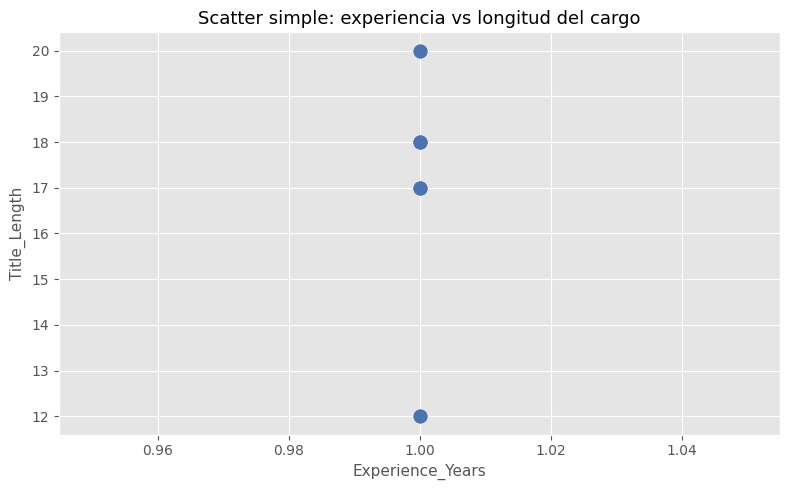

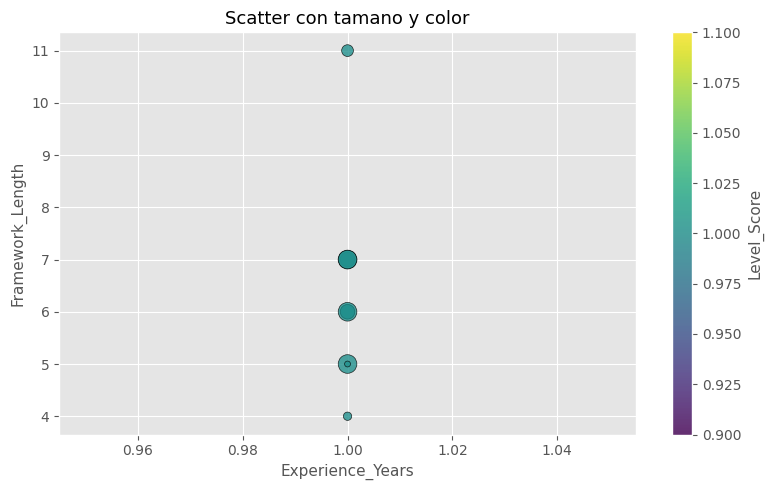

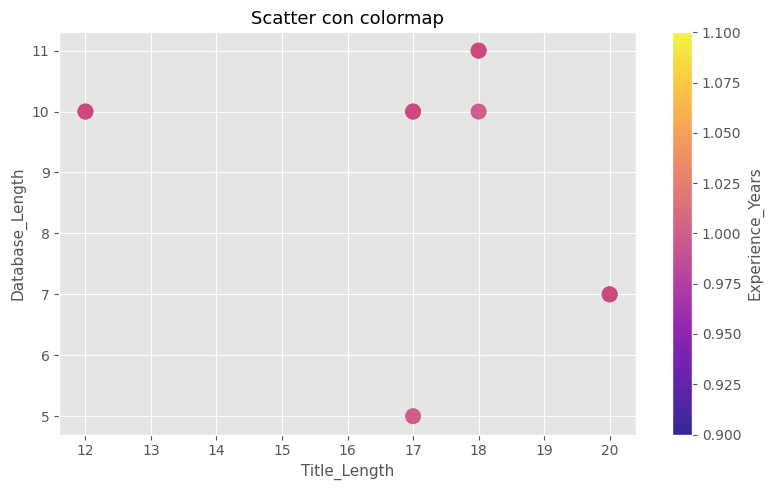

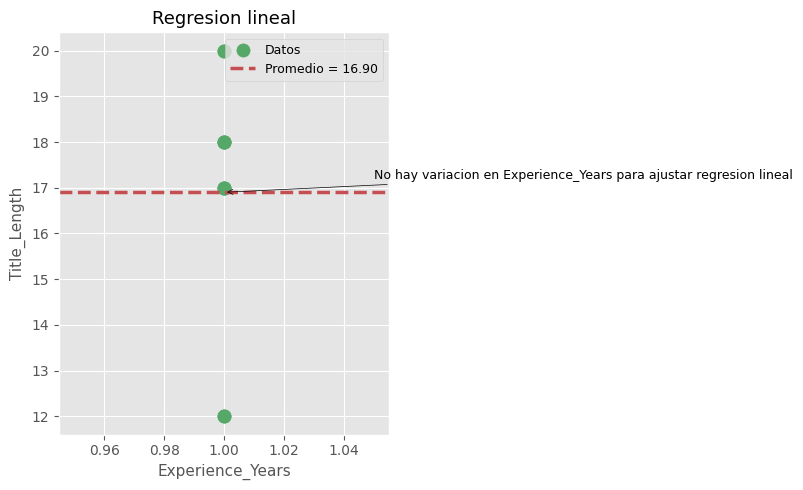

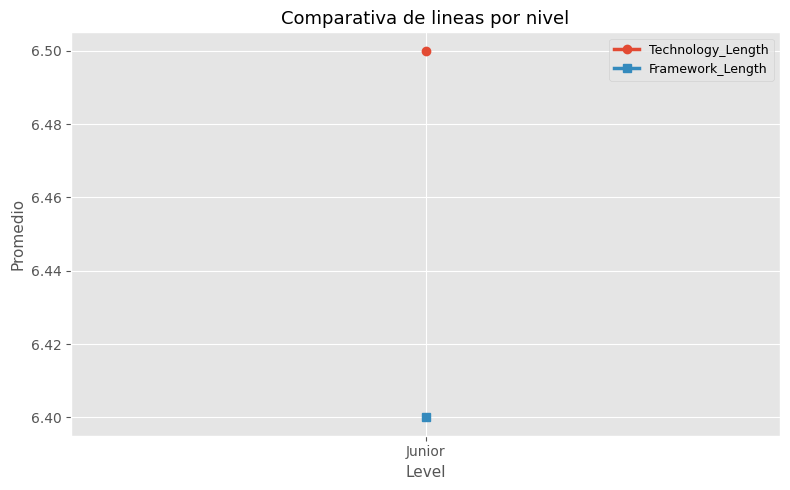

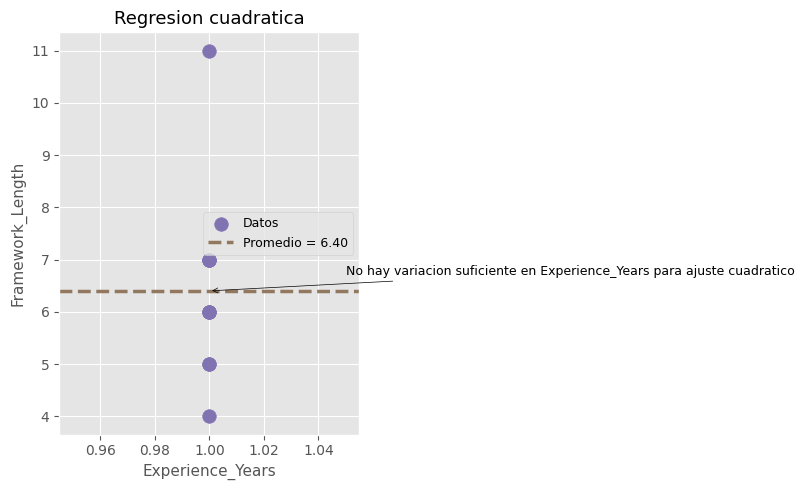

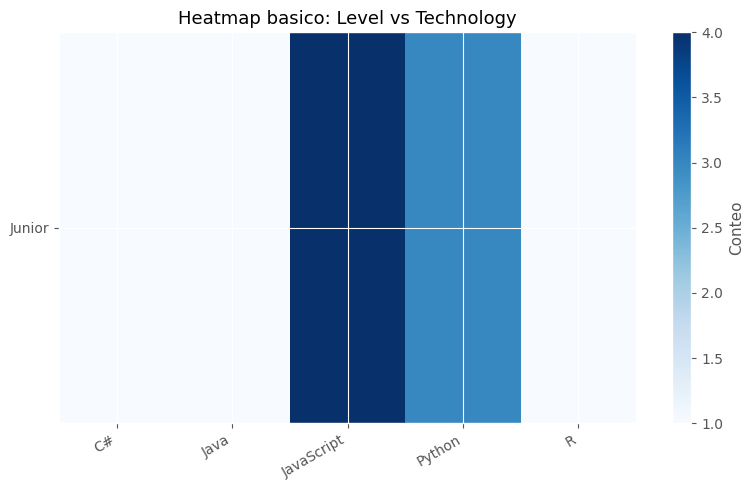

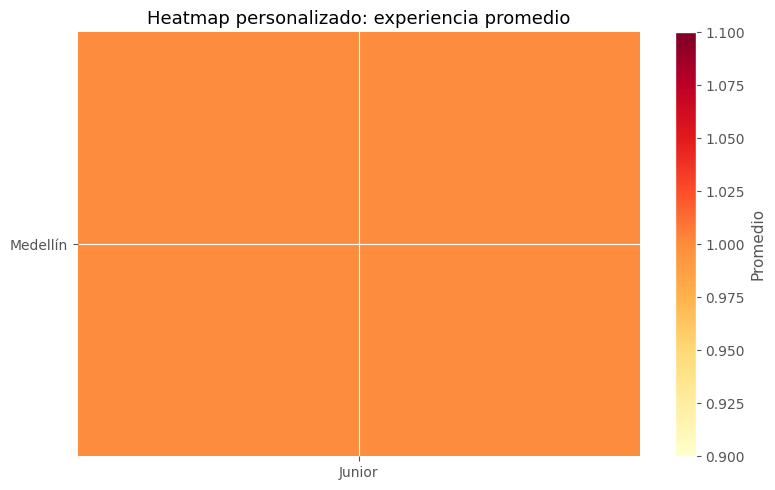

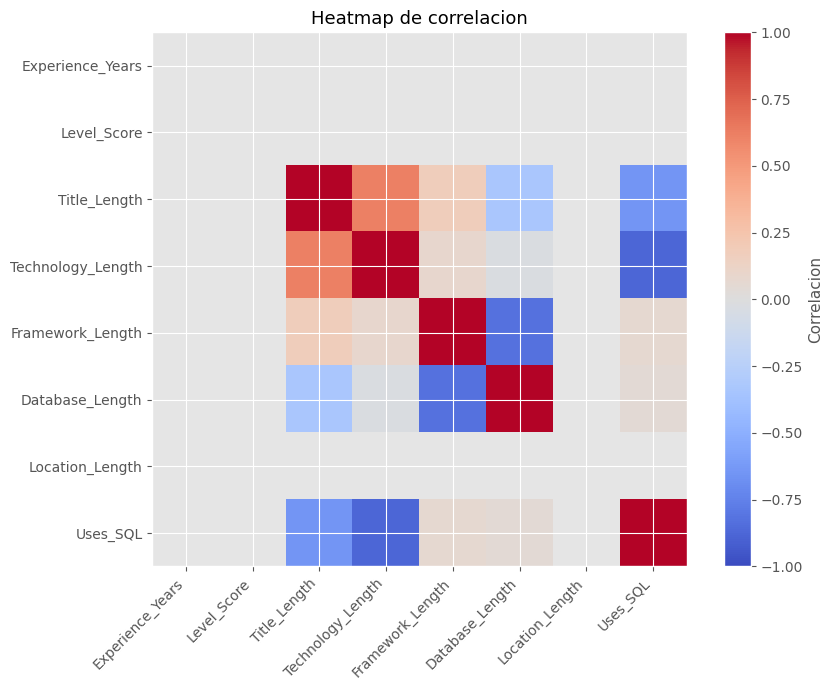

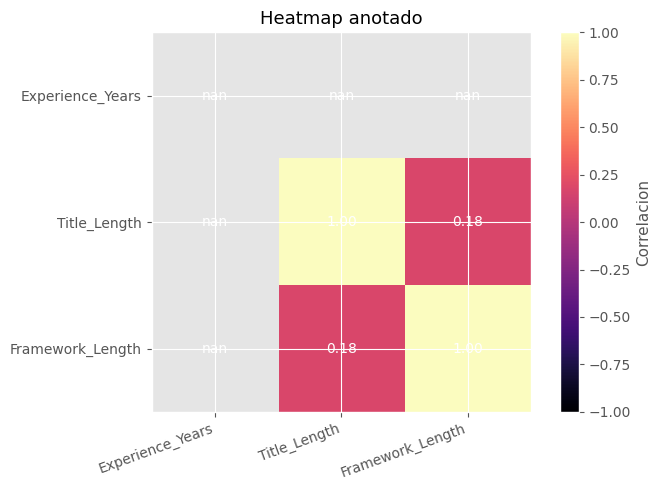

In [5]:
level_palette = df["Level_Score"].to_numpy()
size_values = (df["Technology_Length"] * 18).to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Experience_Years"], df["Title_Length"], color="#4C72B0", s=90)
ax.set_title("Scatter simple: experiencia vs longitud del cargo")
ax.set_xlabel("Experience_Years")
ax.set_ylabel("Title_Length")
fig.tight_layout()
save_evidence(fig, "D1_scatter_simple")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df["Experience_Years"], df["Framework_Length"], s=size_values, c=level_palette, alpha=0.8, cmap="viridis", edgecolors="black")
ax.set_title("Scatter con tamano y color")
ax.set_xlabel("Experience_Years")
ax.set_ylabel("Framework_Length")
fig.colorbar(scatter, ax=ax, label="Level_Score")
fig.tight_layout()
save_evidence(fig, "D2_scatter_tamano_color")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df["Title_Length"], df["Database_Length"], c=df["Experience_Years"], cmap="plasma", s=120, alpha=0.85)
ax.set_title("Scatter con colormap")
ax.set_xlabel("Title_Length")
ax.set_ylabel("Database_Length")
fig.colorbar(scatter, ax=ax, label="Experience_Years")
fig.tight_layout()
save_evidence(fig, "D3_scatter_colormap")
plt.show()

x = df["Experience_Years"].to_numpy()
y = df["Title_Length"].to_numpy()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="#55A868", s=90, label="Datos")
if np.unique(x).size > 1:
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, color="#C44E52", linewidth=2.5, label=f"y = {m:.2f}x + {b:.2f}")
else:
    mean_y = y.mean()
    ax.axhline(mean_y, color="#C44E52", linewidth=2.5, linestyle="--", label=f"Promedio = {mean_y:.2f}")
    ax.annotate("No hay variacion en Experience_Years para ajustar regresion lineal", xy=(x[0], mean_y), xytext=(x[0] + 0.05, mean_y + 0.3), fontsize=9, arrowprops={"arrowstyle": "->", "color": "black"})
ax.set_title("Regresion lineal")
ax.set_xlabel("Experience_Years")
ax.set_ylabel("Title_Length")
ax.legend()
fig.tight_layout()
save_evidence(fig, "D4_regresion_lineal")
plt.show()

line_df = df.groupby("Level", as_index=False)[["Technology_Length", "Framework_Length"]].mean()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_df["Level"], line_df["Technology_Length"], marker="o", linewidth=2.5, label="Technology_Length")
ax.plot(line_df["Level"], line_df["Framework_Length"], marker="s", linewidth=2.5, label="Framework_Length")
ax.set_title("Comparativa de lineas por nivel")
ax.set_xlabel("Level")
ax.set_ylabel("Promedio")
ax.legend()
fig.tight_layout()
save_evidence(fig, "D5_comparativa_lineas")
plt.show()

xq = df["Experience_Years"].to_numpy()
yq = df["Framework_Length"].to_numpy()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xq, yq, color="#8172B2", s=95, label="Datos")
if np.unique(xq).size > 2:
    coef = np.polyfit(xq, yq, 2)
    poly = np.poly1d(coef)
    x_curve = np.linspace(xq.min(), xq.max(), 100)
    ax.plot(x_curve, poly(x_curve), color="#937860", linewidth=2.5, label="Ajuste cuadratico")
else:
    mean_yq = yq.mean()
    ax.axhline(mean_yq, color="#937860", linewidth=2.5, linestyle="--", label=f"Promedio = {mean_yq:.2f}")
    ax.annotate("No hay variacion suficiente en Experience_Years para ajuste cuadratico", xy=(xq[0], mean_yq), xytext=(xq[0] + 0.05, mean_yq + 0.3), fontsize=9, arrowprops={"arrowstyle": "->", "color": "black"})
ax.set_title("Regresion cuadratica")
ax.set_xlabel("Experience_Years")
ax.set_ylabel("Framework_Length")
ax.legend()
fig.tight_layout()
save_evidence(fig, "D6_regresion_cuadratica")
plt.show()

heat_basic = pd.crosstab(df["Level"], df["Technology"])
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat_basic.values, cmap="Blues", aspect="auto")
ax.set_title("Heatmap basico: Level vs Technology")
ax.set_xticks(np.arange(len(heat_basic.columns)))
ax.set_xticklabels(heat_basic.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(heat_basic.index)))
ax.set_yticklabels(heat_basic.index)
fig.colorbar(im, ax=ax, label="Conteo")
fig.tight_layout()
save_evidence(fig, "D7_heatmap_basico")
plt.show()

heat_custom = pd.pivot_table(df, index="Location", columns="Level", values="Experience_Years", aggfunc="mean", fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat_custom.values, cmap="YlOrRd", aspect="auto")
ax.set_title("Heatmap personalizado: experiencia promedio")
ax.set_xticks(np.arange(len(heat_custom.columns)))
ax.set_xticklabels(heat_custom.columns)
ax.set_yticks(np.arange(len(heat_custom.index)))
ax.set_yticklabels(heat_custom.index)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, label="Promedio")
fig.tight_layout()
save_evidence(fig, "D8_heatmap_personalizado")
plt.show()

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Heatmap de correlacion")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, label="Correlacion")
fig.tight_layout()
save_evidence(fig, "D9_heatmap_correlacion")
plt.show()

selected = corr.loc[["Experience_Years", "Title_Length", "Framework_Length"], ["Experience_Years", "Title_Length", "Framework_Length"]]
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(selected.values, cmap="magma", vmin=-1, vmax=1)
ax.set_title("Heatmap anotado")
ax.set_xticks(np.arange(len(selected.columns)))
ax.set_xticklabels(selected.columns, rotation=20, ha="right")
ax.set_yticks(np.arange(len(selected.index)))
ax.set_yticklabels(selected.index)
for i in range(selected.shape[0]):
    for j in range(selected.shape[1]):
        ax.text(j, i, f"{selected.iloc[i, j]:.2f}", ha="center", va="center", color="white", fontsize=10)
fig.colorbar(im, ax=ax, label="Correlacion")
fig.tight_layout()
save_evidence(fig, "D10_heatmap_anotado")
plt.show()

## E. Cuatro graficas categoricas

Se incluyen cuatro variantes de graficas de barras sobre variables categoricas del dataset.

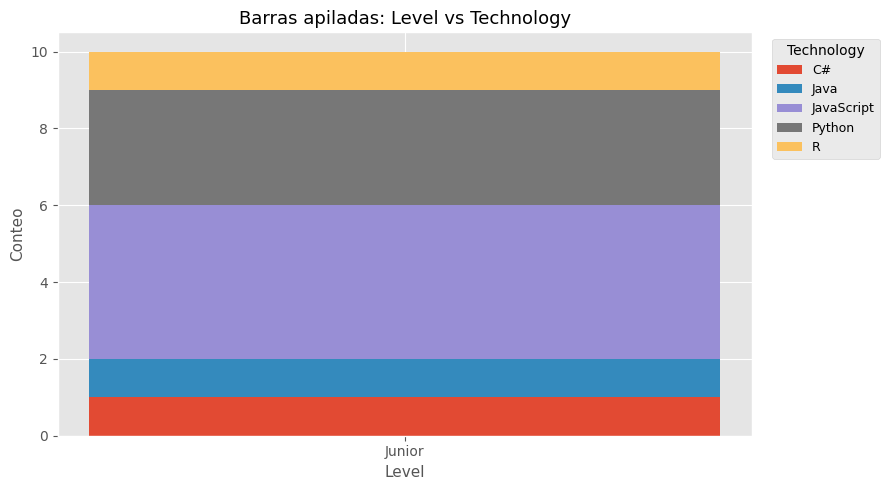

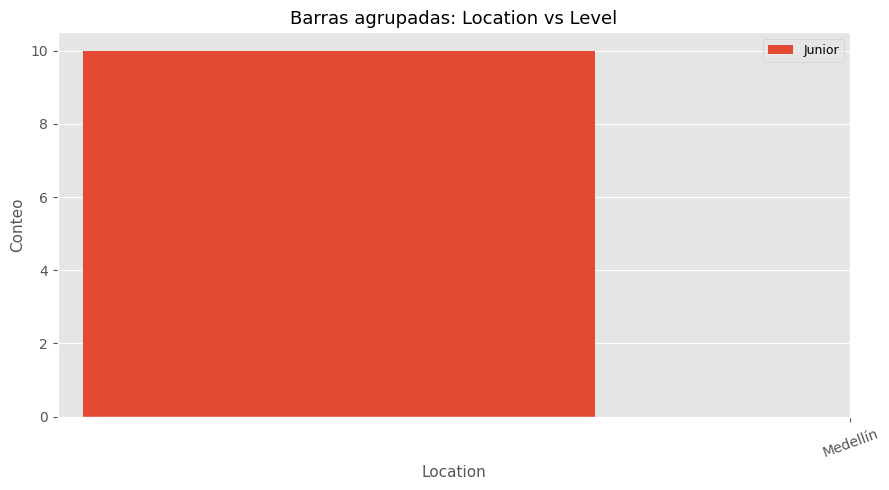

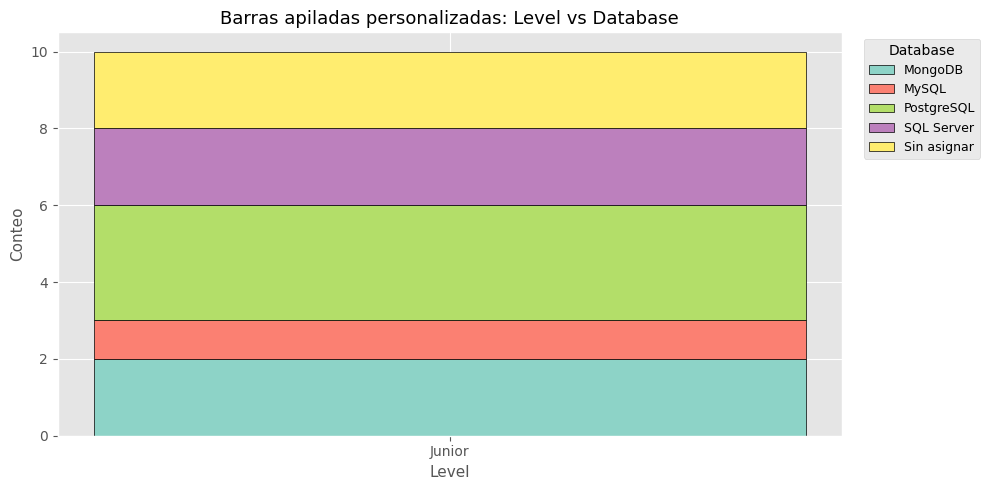

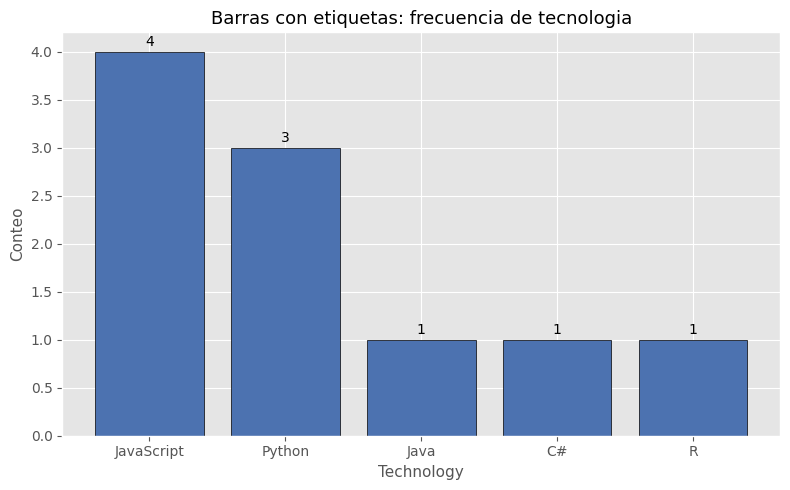

In [6]:
stacked = pd.crosstab(df["Level"], df["Technology"])
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(stacked))
for col in stacked.columns:
    ax.bar(stacked.index, stacked[col].values, bottom=bottom, label=col)
    bottom += stacked[col].values
ax.set_title("Barras apiladas: Level vs Technology")
ax.set_xlabel("Level")
ax.set_ylabel("Conteo")
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_evidence(fig, "E1_barras_apiladas")
plt.show()

grouped = pd.crosstab(df["Location"], df["Level"])
x = np.arange(len(grouped.index))
width = 0.22
fig, ax = plt.subplots(figsize=(9, 5))
for idx, col in enumerate(grouped.columns):
    ax.bar(x + (idx - 1) * width, grouped[col].values, width=width, label=col)
ax.set_title("Barras agrupadas: Location vs Level")
ax.set_xlabel("Location")
ax.set_ylabel("Conteo")
ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=20)
ax.legend()
fig.tight_layout()
save_evidence(fig, "E2_barras_agrupadas")
plt.show()

stacked_db = pd.crosstab(df["Level"], df["Database"])
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(stacked_db))
colors = plt.cm.Set3(np.linspace(0, 1, len(stacked_db.columns)))
for color, col in zip(colors, stacked_db.columns):
    ax.bar(stacked_db.index, stacked_db[col].values, bottom=bottom, label=col, color=color, edgecolor="black")
    bottom += stacked_db[col].values
ax.set_title("Barras apiladas personalizadas: Level vs Database")
ax.set_xlabel("Level")
ax.set_ylabel("Conteo")
ax.legend(title="Database", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_evidence(fig, "E3_barras_apiladas_personalizadas")
plt.show()

bar_counts = df["Technology"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bar_counts.index, bar_counts.values, color="#4C72B0", edgecolor="black")
ax.set_title("Barras con etiquetas: frecuencia de tecnologia")
ax.set_xlabel("Technology")
ax.set_ylabel("Conteo")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03, int(bar.get_height()), ha="center", va="bottom")
fig.tight_layout()
save_evidence(fig, "E4_barras_con_etiquetas")
plt.show()

## Reflexion tecnica final

### 1. Que aprendizaje tecnico deja la diferencia entre `pyplot` y el enfoque OO?

El enfoque OO ofrece mayor control y orden cuando el notebook crece en complejidad, especialmente si se necesitan multiples subplots, anotaciones y exportaciones consistentes.

### 2. Por que no existe una grafica universal para todos los casos?

Porque cada variable comunica algo distinto. La forma correcta depende del tipo de dato, del objetivo del analisis y del nivel de detalle que se quiera resaltar.

### 3. Que aporte concreto tiene `savefig()` en una evidencia academica?

Permite conservar resultados verificables y reutilizables. En esta evidencia se usaron exportaciones reales para poblar la carpeta `artifacts/ev08`.